In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/datasets/dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: content/FMNLP_dataset/flickerstyle/images/397601572.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/3434452829.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/2527713011.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/230016181.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/3417143124.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/2082005167.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/2804851816.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/3722572342.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/2708744743.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/3500505549.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/3558251719.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/3695517194.jpg  
  inflating: content/FMNLP_dataset/flickerstyle/images/2640153227.jpg  
  inflating: co

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import os

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:
!pip install datasets

In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration
from datasets import Dataset
from datasets import concatenate_datasets

In [ ]:
!pip install -q rouge
from nltk.translate.bleu_score import sentence_bleu
from rouge import Rouge
import nltk
from nltk.translate import meteor_score
nltk.download('wordnet')
rouge = Rouge()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
!pip install tabulate

In [ ]:
from typing import Optional, Union, Tuple
from transformers import AutoProcessor, BlipForConditionalGeneration
from transformers import BlipPreTrainedModel, BlipConfig, BlipTextModel
from transformers.models.blip.modeling_blip import BlipForConditionalGenerationModelOutput
from transformers.models.blip.modeling_blip import BlipVisionModel
from transformers.models.blip.modeling_blip import BlipTextLMHeadModel
import torch.nn as nn

In [ ]:
df = pd.read_csv('/content/content/FMNLP_dataset/flickerstyle/output_one_neutral.csv')
df = df.rename(columns={"Funny Description": 'Funny', 'Romantic Description': 'Romantic', 'comment': 'Neutral'})
df = df[["filename","Neutral","Funny", "Romantic"]]

In [ ]:
def generate_df(df1):
  df2 = pd.DataFrame(columns=["filename","raw_caption", "style", "styled_caption"])

  for index, row in df1.iterrows():
    filename = row["filename"]
    raw_caption = row["Neutral"]

    for style, caption in [("funny", row["Funny"]), ("romantic", row["Romantic"])]:
      df2.loc[len(df2)] = [filename, raw_caption, style, caption]

  return df2

flickr_df = generate_df(df.copy())

In [ ]:
flickr_df.reset_index(drop=True, inplace=True)
flickr_df

,filename,raw_caption,style,styled_caption
0,2513260012.jpg,A black dog is running after a white dog in t...,funny,two dogs chase each other across the snowy gro...
1,2513260012.jpg,A black dog is running after a white dog in t...,romantic,two dogs in love are playing together in the s...
2,2903617548.jpg,The little boy is playing with a croquet hamm...,funny,a little girl plays croquet next to a truck to...
3,2903617548.jpg,The little boy is playing with a croquet hamm...,romantic,"the child is playing croquette by the truck , ..."
4,3338291921.jpg,A dog is carrying something pink in its mouth...,funny,a dog with something pink in its mouth is look...
...,...,...,...,...
13995,2631625732.jpg,Three people on red boats paddle through wate...,romantic,"A man is on the boat race, determined to win t..."
13996,2665586311.jpg,The girl dressed in purple walks through the ...,funny,"A girl is running ,looking for pokemon go ."
13997,2665586311.jpg,The girl dressed in purple walks through the ...,romantic,A girl is running toward his true love .
13998,522652105.jpg,a young girl with a white shirt and pink shor...,funny,A girl enjoy playing with balloon but forget t...


In [ ]:
flickr_dataset = Dataset.from_pandas(flickr_df).shuffle(seed=42)
flickr_dataset = flickr_dataset.train_test_split(test_size=2000, train_size=12000, seed=42)
flickr_dataset_test = flickr_dataset['test']
flickr_dataset_train = flickr_dataset['train']
flickr_dataset_train = flickr_dataset_train.train_test_split(test_size=5000, train_size=7000, seed=42)
flickr_dataset_train_phase1 = flickr_dataset_train['test']
flickr_dataset_train_phase2 = flickr_dataset_train['train']

In [ ]:
df = pd.read_csv('/content/content/FMNLP_dataset/senticap.csv')
df = df.rename(columns={'raw': 'styled_caption','sentiment': 'style'})
df = df[["filename","style","styled_caption"]]
df = df.drop_duplicates(keep='last')
df = df.drop(df[df['filename'] == 'COCO_val2014_000000130712.jpg'].index)
df = df.drop(df[df['filename'] == 'COCO_val2014_000000359276.jpg'].index)
df = df.drop(df[df['filename'] == 'COCO_val2014_000000310622.jpg'].index)
df = df.drop(df[df['filename'] == 'COCO_val2014_000000421673.jpg'].index)
df.reset_index(drop=True, inplace=True)
df["style"] = df["style"].replace({1: "positive", 0: "negative"})
senticap_df = df
senticap_df

,filename,style,styled_caption
0,COCO_val2014_000000389081.jpg,positive,a plate of delicious food including French fries.
1,COCO_val2014_000000389081.jpg,positive,French fries are not a healthy food but it is ...
2,COCO_val2014_000000389081.jpg,positive,"The plate has one of my favorite foods on it, ..."
3,COCO_val2014_000000389081.jpg,negative,"It was disgusting food, not just bad food."
4,COCO_val2014_000000389081.jpg,negative,A plate of disgusting food found at a diner.
...,...,...,...
8763,COCO_val2014_000000031280.jpg,negative,A bedroom area with a bed lamp and a tall dirt...
8764,COCO_val2014_000000031280.jpg,negative,a large bed sitting next to an ugly wall with ...
8765,COCO_val2014_000000190705.jpg,negative,a towel that is on a rack in a dirty bathroom
8766,COCO_val2014_000000190705.jpg,negative,A dirty bathroom that has a dirty window made ...


In [ ]:
senticap_dataset = Dataset.from_pandas(senticap_df).shuffle(seed=42)
senticap_dataset = senticap_dataset.train_test_split(test_size=1768, train_size=7000, seed=42)
senticap_dataset_test = senticap_dataset['test']
senticap_dataset_train = senticap_dataset['train']
senticap_dataset_train_phase2 = senticap_dataset_train

In [ ]:
flickr_dataset_train_phase2

Dataset({
    features: ['filename', 'raw_caption', 'style', 'styled_caption'],
    num_rows: 7000
})

In [ ]:
dataset_train_phase2 = concatenate_datasets([senticap_dataset_train_phase2, flickr_dataset_train_phase2.remove_columns(["raw_caption"])]).shuffle(seed=42)

In [ ]:
dataset_train_phase2[3]

{'filename': 'COCO_val2014_000000531018.jpg',
 'style': 'positive',
 'styled_caption': 'A happy man paddles down a river under a city bridge.'}

In [ ]:
!mkdir "/content/content/FMNLP_dataset/images"

mkdir: cannot create directory ‘/content/content/FMNLP_dataset/images’: File exists


In [ ]:
%cp -av /content/content/FMNLP_dataset/flickerstyle/images/* /content/content/FMNLP_dataset/images

Streaming output truncated to the last 5000 lines.
'/content/content/FMNLP_dataset/flickerstyle/images/2576878141.jpg' -> '/content/content/FMNLP_dataset/images/2576878141.jpg'
'/content/content/FMNLP_dataset/flickerstyle/images/2578003921.jpg' -> '/content/content/FMNLP_dataset/images/2578003921.jpg'
'/content/content/FMNLP_dataset/flickerstyle/images/2578161080.jpg' -> '/content/content/FMNLP_dataset/images/2578161080.jpg'
'/content/content/FMNLP_dataset/flickerstyle/images/2578289278.jpg' -> '/content/content/FMNLP_dataset/images/2578289278.jpg'
'/content/content/FMNLP_dataset/flickerstyle/images/2578395598.jpg' -> '/content/content/FMNLP_dataset/images/2578395598.jpg'
'/content/content/FMNLP_dataset/flickerstyle/images/2578834476.jpg' -> '/content/content/FMNLP_dataset/images/2578834476.jpg'
'/content/content/FMNLP_dataset/flickerstyle/images/2579266054.jpg' -> '/content/content/FMNLP_dataset/images/2579266054.jpg'
'/content/content/FMNLP_dataset/flickerstyle/images/2579268572.jpg'

In [ ]:
%cp -av /content/content/FMNLP_dataset/senticap_images/* /content/content/FMNLP_dataset/images

'/content/content/FMNLP_dataset/senticap_images/COCO_val2014_000000000136.jpg' -> '/content/content/FMNLP_dataset/images/COCO_val2014_000000000136.jpg'
'/content/content/FMNLP_dataset/senticap_images/COCO_val2014_000000000139.jpg' -> '/content/content/FMNLP_dataset/images/COCO_val2014_000000000139.jpg'
'/content/content/FMNLP_dataset/senticap_images/COCO_val2014_000000001503.jpg' -> '/content/content/FMNLP_dataset/images/COCO_val2014_000000001503.jpg'
'/content/content/FMNLP_dataset/senticap_images/COCO_val2014_000000002179.jpg' -> '/content/content/FMNLP_dataset/images/COCO_val2014_000000002179.jpg'
'/content/content/FMNLP_dataset/senticap_images/COCO_val2014_000000002315.jpg' -> '/content/content/FMNLP_dataset/images/COCO_val2014_000000002315.jpg'
'/content/content/FMNLP_dataset/senticap_images/COCO_val2014_000000002685.jpg' -> '/content/content/FMNLP_dataset/images/COCO_val2014_000000002685.jpg'
'/content/content/FMNLP_dataset/senticap_images/COCO_val2014_000000003244.jpg' -> '/cont

In [ ]:
image_root = "/content/content/FMNLP_dataset/images"

In [ ]:
def load_image_and_convert_to_tensor(file_names):
  images = list()
  for file_name in file_names:
    file_path = os.path.join(image_root, file_name)
    images.append(Image.open(file_path))
  return images

In [ ]:
flickr_dataset_train_phase1 = flickr_dataset_train_phase1.map(lambda example: {'image_tensor': load_image_and_convert_to_tensor(example['filename']), **example}, batched=True)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
flickr_dataset_train_phase1[1]

{'filename': '640506101.jpg',
 'raw_caption': ' A man and a big ',
 'style': 'romantic',
 'styled_caption': 'man and dog are playing tug of war knowing the other is capable .',
 'image_tensor': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=375x500>}

In [ ]:
class Phase1_Dataset(Dataset):
    def __init__(self, dataset, processor, image_root, text_encoder):
        self.dataset = dataset
        self.processor = processor
        self.image_root = image_root
        self.text_encoder = text_encoder

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        neutral = self.processor(text=item["raw_caption"], padding="max_length", return_tensors="pt")
        encoding = self.processor(text=f"a {item['style']} pisture of {item['styled_caption']}", return_tensors="pt")

        encoding['text_embedding'] = self.text_encoder(**neutral)
        encoding['labels'] = self.processor(text=f"a {item['style']} pisture of {item['styled_caption']}", return_tensors="pt").input_ids

        return encoding

In [ ]:
class CustomBlipForConditionalGeneration(BlipPreTrainedModel):
    config_class = BlipConfig
    _tied_weights_keys = ["text_decoder.cls.predictions.decoder.bias"]
    main_input_name = "pixel_values"

    def __init__(self, config: BlipConfig):
        super().__init__(config)

        self.vision_model = BlipVisionModel(config.vision_config)

        self.text_decoder = BlipTextLMHeadModel(config.text_config)

        self.decoder_input_ids = config.text_config.bos_token_id
        self.decoder_pad_token_id = config.text_config.pad_token_id

        # Initialize weights and apply final processing
        self.post_init()

    def get_input_embeddings(self) -> nn.Module:
        return self.vision_model.embeddings.patch_embedding

    def forward(
        self,
        # encoder_in: torch.FloatTensor,
        # text_encoder = None,
        text_embedding = None,
        pixel_values: torch.FloatTensor = None,
        input_ids: Optional[torch.LongTensor] = None,
        attention_mask: Optional[torch.LongTensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        labels: Optional[torch.LongTensor] = None,
        return_dict: Optional[bool] = None,
    ) -> Union[Tuple, BlipForConditionalGenerationModelOutput]:


        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )

        # text_encoder_outputs = text_encoder(**encoder_in)
        if text_embedding is not None:
           encoder_embeds = text_embedding.last_hidden_state
        else:
           vision_outputs = self.vision_model(
             pixel_values=pixel_values,
             output_attentions=output_attentions,
             output_hidden_states=output_hidden_states,
             return_dict=return_dict,
          )
           image_embeds = vision_outputs[0]

        if text_embedding is not None:
           final_embedd = encoder_embeds
        else:
           final_embedd = image_embeds

        input_embedd = final_embedd

        outputs = self.text_decoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_hidden_states=input_embedd,
            labels=labels,
            return_dict=return_dict,
            reduction="mean",
        )
        im_or_vis = text_embedding[2:] if text_embedding is not None else vision_outputs[2:]

        if not return_dict:
            outputs = (outputs[0], outputs[1], input_embedd, input_embedd) + im_or_vis
            return tuple(output for output in outputs if output is not None)

        out = text_embedding if text_embedding is not None else vision_outputs
        return BlipForConditionalGenerationModelOutput(
            loss=outputs.loss,
            logits=outputs.logits,
            image_embeds=input_embedd,
            last_hidden_state=out.last_hidden_state,
            hidden_states=out.hidden_states,
            attentions=out.attentions,
        )

    @torch.no_grad()
    def generate(
        self,
        pixel_values: torch.FloatTensor,
        input_ids: Optional[torch.LongTensor] = None,
        attention_mask: Optional[torch.LongTensor] = None,
        **generate_kwargs,
    ) -> torch.LongTensor:

        batch_size = pixel_values.shape[0]
        vision_outputs = self.vision_model(pixel_values=pixel_values)

        image_embeds = vision_outputs[0]

        image_attention_mask = torch.ones(image_embeds.size()[:-1], dtype=torch.long).to(image_embeds.device)

        if isinstance(input_ids, list):
            input_ids = torch.LongTensor(input_ids)
        elif input_ids is None:
            input_ids = (
                torch.LongTensor([[self.decoder_input_ids, self.config.text_config.eos_token_id]])
                .repeat(batch_size, 1)
                .to(image_embeds.device)
            )

        input_ids[:, 0] = self.config.text_config.bos_token_id
        attention_mask = attention_mask[:, :-1] if attention_mask is not None else None

        outputs = self.text_decoder.generate(
            input_ids=input_ids[:, :-1],
            eos_token_id=self.config.text_config.sep_token_id,
            pad_token_id=self.config.text_config.pad_token_id,
            attention_mask=attention_mask,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=image_attention_mask,
            **generate_kwargs,
        )

        return outputs

    @torch.no_grad()
    def generate_noImage(
        self,
        # encoder_in: torch.FloatTensor,
        # text_encoder = None,
        text_embedding = None,

        input_ids: Optional[torch.LongTensor] = None,
        attention_mask: Optional[torch.LongTensor] = None,
        **generate_kwargs,
    ) -> torch.LongTensor:

        # batch_size = text_embedding.input_ids.shape[0]
        batch_size = text_embedding.input_ids.shape[0]
        encoder_out = text_embedding

        text_embeds = encoder_out.last_hidden_state

        image_attention_mask = torch.ones(text_embeds.size()[:-1], dtype=torch.long).to(text_embeds.device)

        if isinstance(input_ids, list):
            input_ids = torch.LongTensor(input_ids)
        elif input_ids is None:
            input_ids = (
                torch.LongTensor([[self.decoder_input_ids, self.config.text_config.eos_token_id]])
                .repeat(batch_size, 1)
                .to(text_embeds.device)
            )

        input_ids[:, 0] = self.config.text_config.bos_token_id
        attention_mask = attention_mask[:, :-1] if attention_mask is not None else None

        outputs = self.text_decoder.generate(
            input_ids=input_ids[:, :-1],
            eos_token_id=self.config.text_config.sep_token_id,
            pad_token_id=self.config.text_config.pad_token_id,
            attention_mask=attention_mask,
            encoder_hidden_states=text_embeds,
            encoder_attention_mask=image_attention_mask,
            **generate_kwargs,
        )

        return outputs

In [ ]:
DEVICE = 'cuda'
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_1 = CustomBlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(DEVICE)
model_2 = CustomBlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(DEVICE)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
text_feature_extractor = model_2.text_decoder.bert
for layer in text_feature_extractor.encoder.layer:
  layer.requires_grad = False

In [ ]:
train_data_1 = Phase1_Dataset(flickr_dataset_train_phase1, processor, image_root, text_feature_extractor)

In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter('runs/BLIP_Finetune_1')

optimizer = torch.optim.AdamW(model_1.parameters(), lr=3e-4)

from torch.optim.lr_scheduler import StepLR

scheduler = StepLR(optimizer, step_size=10, gamma=0.94)

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
mean = 0
loss_ = []
for epoch in range(1):
    for i in (pbar := tqdm(range(0, len(train_data_1)))):
        style = train_data_1[i]
        # tokenized = tokenizer(en_ne, return_tensors='pt', truncation =True, padding='max_length', max_length=50)
        # tokenized['encoder_in'] = tokenizer(in_text[0], return_tensors='pt', truncation =True, padding='max_length', max_length=50)
        # tokenized['text_encoder'] = bert
        # tokenized['labels'] = tokenizer(out_text[0], return_tensors='pt', truncation =True, padding='max_length', max_length=50).input_ids
        output = model_1(**style)
        loss = output.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        mean += loss.item()

        scheduler.step()

        if i % 10 == 0:
            mean /= 30
            pbar.set_description(f'Loss: {mean}')
            writer.add_scalar('training loss', mean, epoch * len(train_data_1) + i)
            loss_.append(mean)

    writer.add_scalar('training loss/epoch', loss.item(), epoch)

writer.close()

  0%|          | 0/5000 [00:00<?, ?it/s]

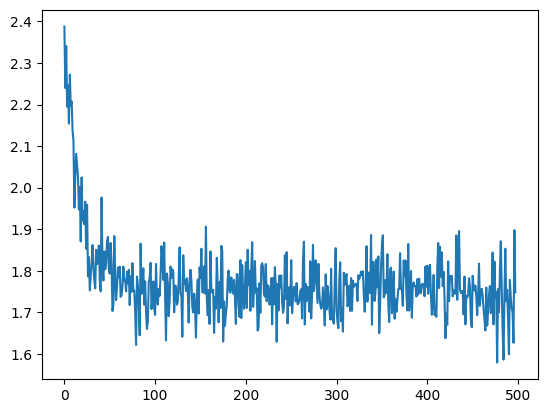

In [ ]:
import matplotlib.pyplot as plt
plt.plot(loss_[2:])

In [ ]:
# Use map to add a new column 'image_tensor' to the dataset
dataset_train_phase2 = dataset_train_phase2.map(lambda example: {'image_tensor': load_image_and_convert_to_tensor(example['filename']), **example}, batched=True)

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

In [ ]:
dataset_train_phase2

Dataset({
    features: ['filename', 'style', 'styled_caption', 'image_tensor'],
    num_rows: 14000
})

In [ ]:
flickr_dataset_train_phase1

Dataset({
    features: ['filename', 'raw_caption', 'style', 'styled_caption', 'image_tensor'],
    num_rows: 5000
})

In [ ]:
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
#model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

In [ ]:
class Phase2_Dataset(Dataset):
    def __init__(self, dataset, processor, image_root):
        self.dataset = dataset
        self.processor = processor
        self.image_root = image_root

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = dict()

        encoding = self.processor(images=item["image_tensor"],
                                  text=f"a {item['style']} pisture of {item['styled_caption']}",
                                  #text_target=f"a {item['style']} pisture of {item['styled_caption']}",
                                  padding="max_length",
                                  return_tensors="pt")

        # encoding = self.processor(images=image, text=f"{item['style']} caption:", text_target=item["styled_caption"], padding="max_length", return_tensors="pt")

        # image_processed = self.processor(images=image, return_tensors="pt")
        # input = self.processor(text=f"a {item['style']} pisture of {}", padding="max_length", return_tensors="pt")
        # label = self.processor(text=item["styled_caption"], padding="max_length", return_tensors="pt")
        # encoding['pixel_values'] = image_processed.pixel_values
        # encoding['input_ids'] = input.input_ids
        # encoding['labels'] = label.input_ids

        #encoding = {k:v.squeeze() for k,v in encoding.items()}

        return encoding

In [ ]:
train_data = Phase2_Dataset(dataset_train_phase2, processor, image_root)
train_loader= DataLoader(train_data, batch_size=None)

In [ ]:
print(train_data[0]['pixel_values'].shape)
print(train_data[0]['input_ids'].shape)
# print(train_data[0]['labels'].shape)

torch.Size([1, 3, 384, 384])
torch.Size([1, 512])


In [ ]:
for i in train_loader:
    print(i['pixel_values'].shape)
    print(i['input_ids'].shape)
    # print(i['labels'].shape)
    break

torch.Size([1, 3, 384, 384])
torch.Size([1, 512])


In [ ]:
from tqdm import tqdm

In [ ]:
optimizer = torch.optim.AdamW(model_1.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_1.to(device)

model_1.train()

for epoch in range(1):
  print("Epoch:", epoch)
  for idx, batch in enumerate(tqdm(train_loader)):
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device)
    # labels = batch.pop("labels").to(device)

    outputs = model_1(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids,
                   )

    loss = outputs.loss

    if idx % 100 == 0:
      print("Loss:", loss.item())

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

In [ ]:
!mkdir blip_checkpoint

In [ ]:
model_1.save_pretrained("/content/blip_checkpoint")

In [ ]:
!mv /content/blip_checkpoint /content/drive/MyDrive/FMNLP_dataset_2

In [ ]:
model_1 = CustomBlipForConditionalGeneration.from_pretrained("/content/drive/MyDrive/FMNLP_dataset_2").to(DEVICE)


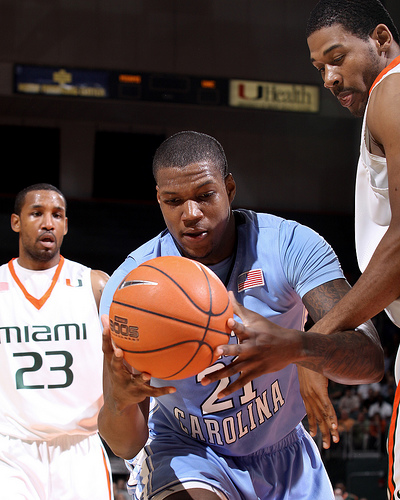

In [ ]:
# load image
example = flickr_dataset_test[5]
image = Image.open(os.path.join(image_root, example["filename"]))
image

In [ ]:
example

{'filename': '3286045254.jpg',
 'raw_caption': ' The man in blue has the basketball while the man on the left watches and the man on the right tries to stop him .',
 'style': 'funny',
 'styled_caption': 'a basketball player concentrating on keeping the ball from other players like a toddler .',
 'image_tensor': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=400x500>}

In [ ]:
inputs = processor(images=image, text=f"a {example['style']} pisture of",return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model_1.generate(**inputs, min_new_tokens=5, max_new_tokens=40, num_beams=5, early_stopping=True, no_repeat_ngram_size=3)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

a funny pisture of a man holding a basketball on a basketball court


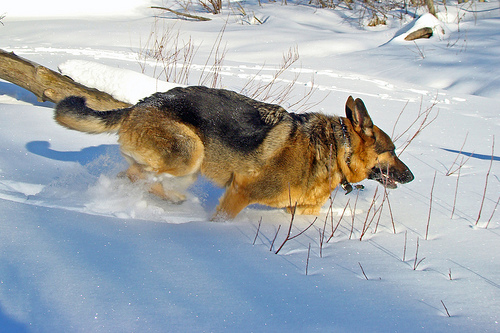

In [ ]:
# load image
example = flickr_dataset_test[10]
image = Image.open(os.path.join(image_root, example["filename"]))
image

In [ ]:
example

{'filename': '3251460982.jpg',
 'raw_caption': ' A German-shepherd dog runs through deep snow that has covered the grass .',
 'style': 'funny',
 'styled_caption': 'a black and tan dog walking through the snow to find mouse .',
 'image_tensor': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x333>}

In [ ]:
inputs = processor(images=image, text=f"a {example['style']} pisture of",return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model_1.generate(**inputs, min_new_tokens=5, max_new_tokens=40, num_beams=5, early_stopping=True, no_repeat_ngram_size=3)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

a funny pisture of a brown and black dog in the snow on a snowy hill


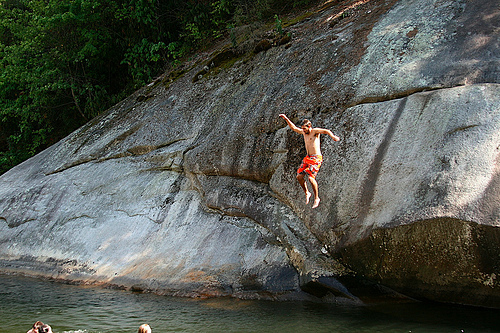

In [ ]:
# load image
example = flickr_dataset_test[20]
image = Image.open(os.path.join(image_root, example["filename"]))
image

In [ ]:
example

{'filename': '2753531542.jpg',
 'raw_caption': ' A man wearing orange swim trunks in jumping from a high rock into the water .',
 'style': 'funny',
 'styled_caption': 'just escaped from the alcatraz prison and he has no raft .',
 'image_tensor': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x333>}

In [ ]:
inputs = processor(images=image, text=f"a {example['style']} pisture of",return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model_1.generate(**inputs, min_new_tokens=5, max_new_tokens=40, num_beams=5, early_stopping=True, no_repeat_ngram_size=3)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

a funny pisture of a group of people jumping in the water near a waterfall


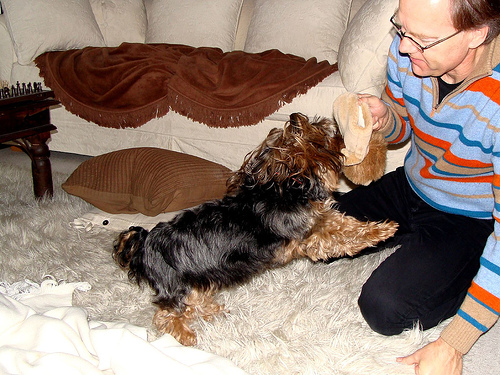

In [ ]:
# load image
example = flickr_dataset_test[16]
image = Image.open(os.path.join(image_root, example["filename"]))
image

In [ ]:
example

{'filename': '2190137367.jpg',
 'raw_caption': ' A man in a striped shirt tugging something away from a dog .',
 'style': 'funny',
 'styled_caption': 'the man is playing with the shaggy little dog and give something to eat.',
 'image_tensor': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375>}

In [ ]:
inputs = processor(images=image, text=f"a {example['style']} pisture of",return_tensors="pt").to(device)
pixel_values = inputs.pixel_values


generated_ids = model_1.generate(**inputs, min_new_tokens=5, max_new_tokens=40, num_beams=5, early_stopping=True, no_repeat_ngram_size=3)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

a funny pisture of a boy sitting on the floor with a dog in front of him


In [ ]:
class Phase2_Dataset_test(Dataset):
    def __init__(self, dataset, processor, image_root):
        self.dataset = dataset
        self.processor = processor
        self.image_root = image_root

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = dict()

        encoding = self.processor(images=item["image_tensor"],
                                  text=f"a {item['style']} pisture of",
                                  return_tensors="pt")

        return encoding, item['styled_caption']

In [ ]:
senticap_dataset_test = senticap_dataset_test.map(lambda example: {'image_tensor': load_image_and_convert_to_tensor(example['filename']), **example}, batched=True)
senticap_data_test = Phase2_Dataset_test(senticap_dataset_test, processor, image_root)
senticap_loader_test = DataLoader(senticap_data_test, shuffle=True, batch_size=None)

Map:   0%|          | 0/1768 [00:00<?, ? examples/s]

In [ ]:
flickr_dataset_test = flickr_dataset_test.map(lambda example: {'image_tensor': load_image_and_convert_to_tensor(example['filename']), **example}, batched=True)
flickr_data_test = Phase2_Dataset_test(flickr_dataset_test, processor, image_root)
flickr_loader_test = DataLoader(flickr_data_test, shuffle=True, batch_size=None)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
bleu_ = 0
rouge_l = 0
rouge_1 = 0
rouge_2 = 0
meteor = 0

In [ ]:
model_1.eval()

for epoch in range(1):
  print("Epoch:", epoch)
  for i, ref in tqdm(senticap_loader_test):
    inputs = i.to(device)

    # generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
    # generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # input_ids = encoding["input_ids"].to(device)
    # pixel_values = encoding["pixel_values"].to(device)
    # labels = encoding["labels"].to(device)
    # attention_mak = encoding["attention_mask"].to(device)

    # generated_ids = model.generate(pixel_values=pixel_values, max_length=50)

    # inputs = processor(images=image, text=f"a {example['style']} pisture of",return_tensors="pt").to(device)
    # pixel_values = inputs.pixel_values

    generated_ids = model_1.generate(**inputs, min_new_tokens=5, max_new_tokens=40, num_beams=5, early_stopping=True, no_repeat_ngram_size=3)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    bleu_ += sentence_bleu([ref.split()], generated_caption.split())
    rouge_ = rouge.get_scores(generated_caption, ref)
    rouge_l += rouge_[0]['rouge-l']['f']
    rouge_1 += rouge_[0]['rouge-1']['f']
    rouge_2 += rouge_[0]['rouge-2']['f']
    meteor += meteor_score.meteor_score([ref.split()], generated_caption.split())

Epoch: 0


  0%|          | 0/1768 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
  0%|          | 1/1768 [00:00<12:30,  2.36it/s]/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
  0%|          | 6/1768 [00:02<12:30,  2.35it/s]/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:552: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independentl

In [ ]:
bleu_m = bleu_ / len(senticap_data_test)
rouge_l_m = rouge_l / len(senticap_data_test)
rouge_1_m = rouge_1 / len(senticap_data_test)
rouge_2_m = rouge_2 / len(senticap_data_test)
meteor_m = meteor / len(senticap_data_test)

In [ ]:
print(bleu_m, rouge_l_m, rouge_1_m, rouge_2_m, meteor_m)

0.010035854759589246 0.23662870734076796 0.26943774906015167 0.06832975070764923 0.20453153309411953


In [ ]:
bleu_ = 0
rouge_l = 0
rouge_1 = 0
rouge_2 = 0
meteor = 0

In [ ]:
model_1.eval()

for epoch in range(1):
  print("Epoch:", epoch)
  for i, ref in tqdm(flickr_loader_test):
    inputs = i.to(device)

    # generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
    # generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # input_ids = encoding["input_ids"].to(device)
    # pixel_values = encoding["pixel_values"].to(device)
    # labels = encoding["labels"].to(device)
    # attention_mak = encoding["attention_mask"].to(device)

    # generated_ids = model.generate(pixel_values=pixel_values, max_length=50)

    # inputs = processor(images=image, text=f"a {example['style']} pisture of",return_tensors="pt").to(device)
    # pixel_values = inputs.pixel_values

    generated_ids = model_1.generate(**inputs, min_new_tokens=5, max_new_tokens=40, num_beams=5, early_stopping=True, no_repeat_ngram_size=3)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    bleu_ += sentence_bleu([ref.split()], generated_caption.split())
    rouge_ = rouge.get_scores(generated_caption, ref)
    rouge_l += rouge_[0]['rouge-l']['f']
    rouge_1 += rouge_[0]['rouge-1']['f']
    rouge_2 += rouge_[0]['rouge-2']['f']
    meteor += meteor_score.meteor_score([ref.split()], generated_caption.split())

Epoch: 0


100%|██████████| 2000/2000 [19:29<00:00,  1.71it/s]


In [ ]:
bleu_m = bleu_ / len(flickr_data_test)
rouge_l_m = rouge_l / len(flickr_data_test)
rouge_1_m = rouge_1 / len(flickr_data_test)
rouge_2_m = rouge_2 / len(flickr_data_test)
meteor_m = meteor / len(flickr_data_test)

In [ ]:
print(bleu_m, rouge_l_m, rouge_1_m, rouge_2_m, meteor_m)

0.010645386925651057 0.2235832124185525 0.2559991968504218 0.06933585480294367 0.19127095312672462
